Weights: [0.1 0.1], Bias: -0.1


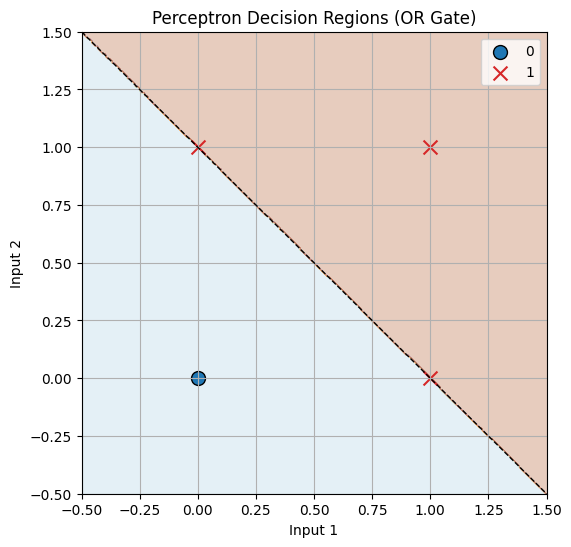

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def train_perceptron(X, y, learning_rate=0.1, epochs=10):
    w = np.zeros(X.shape[1])
    b = 0.0
    for _ in range(epochs):
        for xi, yi in zip(X, y):
            pred = 1 if np.dot(xi, w) + b >= 0 else 0
            error = yi - pred
            w += learning_rate * error * xi
            b += learning_rate * error
    return w, b

def plot_decision_regions(X, y, w, b):
    # Create mesh and predictions
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
    Z = (np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b >= 0).astype(int).reshape(xx.shape)
    
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Paired')
    
    # Plot points
    plt.scatter(X[y==0, 0], X[y==0, 1], marker='o', s=100, edgecolors='k', label='0')
    plt.scatter(X[y==1, 0], X[y==1, 1], marker='x', s=100, color='C3', label='1')
    
    # Decision boundary
    if abs(w[1]) > 1e-8:
        x = np.array([-0.5, 1.5])
        plt.plot(x, -(w[0]*x + b)/w[1], 'k--', linewidth=1)
    
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.title("Perceptron Decision Regions (OR Gate)")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.legend()
    plt.grid(True)
    plt.show()

# Main
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float64)
y = np.array([0, 1, 1, 1], dtype=np.int32)
w, b = train_perceptron(X, y)
print(f"Weights: {w}, Bias: {b}")
plot_decision_regions(X, y, w, b)